In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


In [2]:
df=pd.read_csv("D:\\Data Science Projects\\Machine learning Projects\\Heart Disease Prediction\\Data\\heart.csv")

In [3]:
df

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0
...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,M,TA,110,264,0,Normal,132,N,1.2,Flat,1
914,68,M,ASY,144,193,1,Normal,141,N,3.4,Flat,1
915,57,M,ASY,130,131,0,Normal,115,Y,1.2,Flat,1
916,57,F,ATA,130,236,0,LVH,174,N,0.0,Flat,1


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [5]:
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


**Data Preprocessing**

In [6]:
#Handling zero values
(df[['RestingBP', 'Cholesterol']] == 0).sum()

RestingBP        1
Cholesterol    172
dtype: int64

1. With BP or Cholesterol == 0 it's impossible to live, so need to replace 0s.
2. Since Cholesterol levels often vary by Sex and Gender let's group and take median of it.
3. For BP let's just take mean.

In [7]:
df['Cholesterol'] = df['Cholesterol'].replace(0, np.nan)
df['RestingBP'] = df['RestingBP'].replace(0, np.nan)

df['RestingBP'] = df['RestingBP'].fillna(df['RestingBP'].mean())
df['Cholesterol'] = df.groupby(['Age', 'Sex'])['Cholesterol'].transform(lambda x: x.fillna(x.median()))

df['Cholesterol'] = df['Cholesterol'].fillna(df['Cholesterol'].median())

df.isna().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

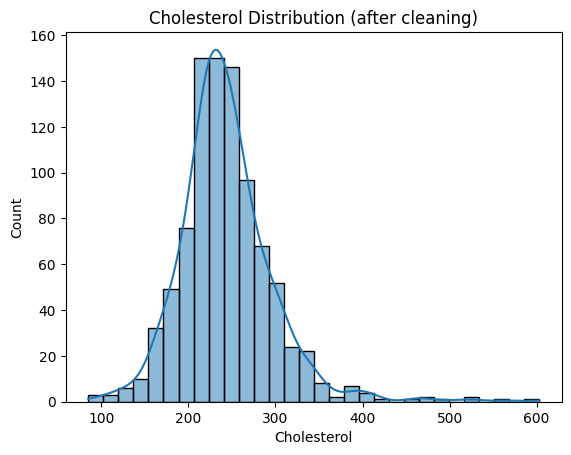

In [8]:
sns.histplot(df['Cholesterol'], bins=30, kde=True)
plt.title('Cholesterol Distribution (after cleaning)')
plt.show()

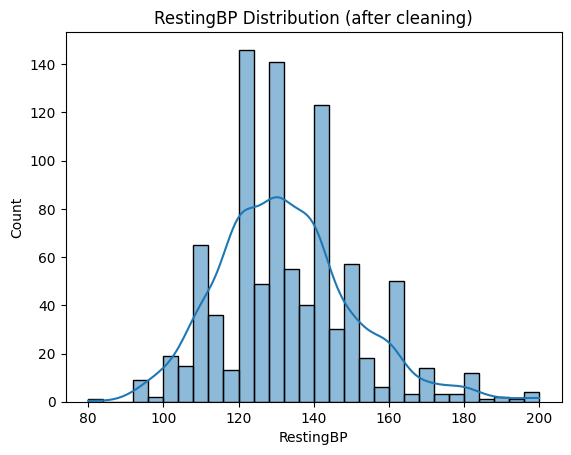

In [9]:
sns.histplot(df['RestingBP'], bins=30, kde=True)
plt.title('RestingBP Distribution (after cleaning)')
plt.show()

In [10]:
df.isnull().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

In [11]:
df.duplicated().sum()

np.int64(0)

**EDA**

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

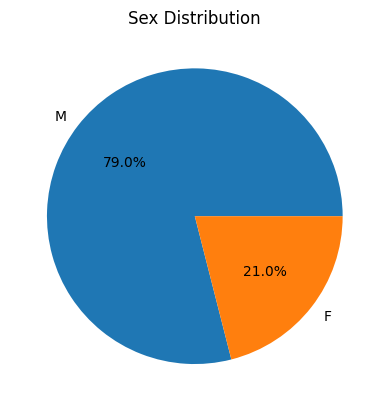

In [13]:
df['Sex'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("Sex Distribution")
plt.ylabel('')
plt.show()

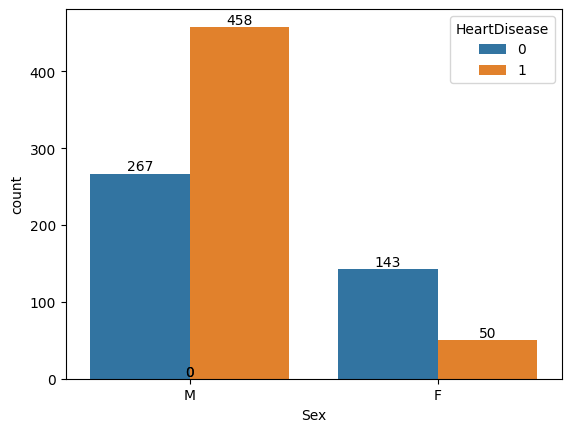

In [14]:
ax = sns.countplot(data=df, x='Sex', hue='HeartDisease')

# Add count labels on bars
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{int(height)}',
                (p.get_x() + p.get_width() / 2, height),
                ha='center', va='bottom')

plt.show()

In [15]:
df1 = df.copy()
df1['Age_Group'] = pd.cut(df1['Age'],
                         bins=[0, 30, 40, 50, 60, 100],
                         labels=['<30', '30-40', '40-50', '50-60', '60+'])

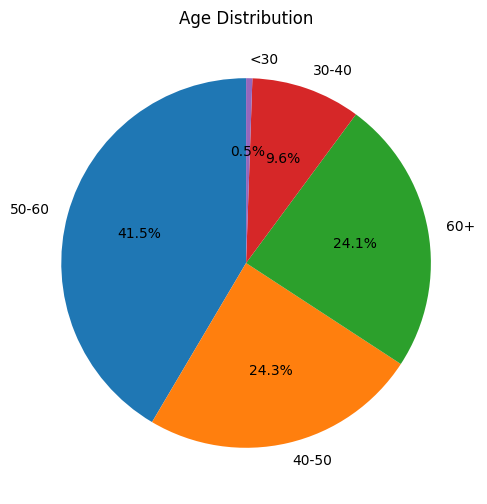

In [16]:

age_counts = df1['Age_Group'].value_counts()

plt.figure(figsize=(6,6))

plt.pie(age_counts,
        labels=age_counts.index,
        autopct='%1.1f%%',
        startangle=90)

plt.title("Age Distribution")
plt.show()

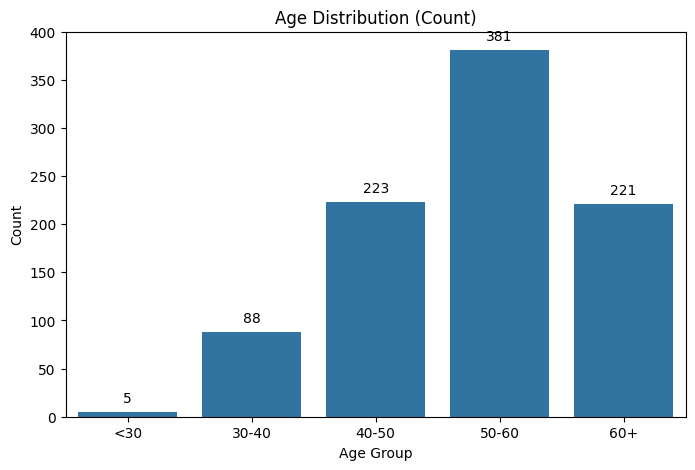

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

ax = sns.countplot(data=df1, x='Age_Group')

# Add count labels
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(f'{int(height)}',
                    (p.get_x() + p.get_width()/2, height),
                    ha='center', va='bottom',
                    xytext=(0,5),
                    textcoords='offset points')

plt.title("Age Distribution (Count)")
plt.xlabel("Age Group")
plt.ylabel("Count")
plt.show()

In [18]:
df1['BP_Category'] = pd.cut(df1['RestingBP'],
                           bins=[0, 90, 120, 140, 200],
                           labels=['Low', 'Normal', 'Elevated', 'High'])

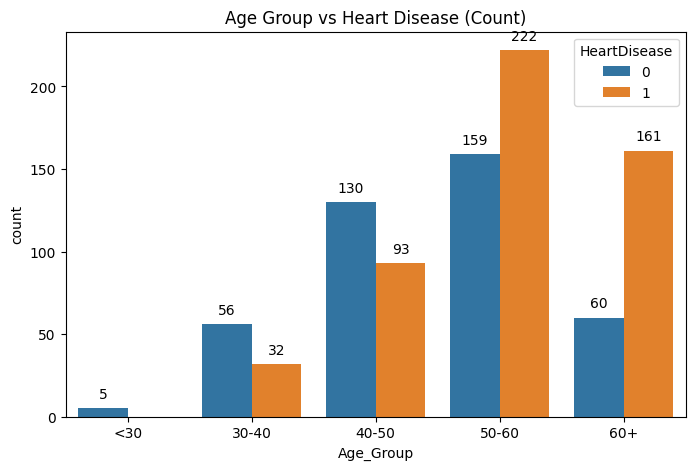

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

ax = sns.countplot(data=df1, x='Age_Group', hue='HeartDisease')

# Add counts
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(f'{int(height)}',
                    (p.get_x() + p.get_width()/2, height),
                    ha='center', va='bottom',
                    xytext=(0,5),
                    textcoords='offset points')

plt.title("Age Group vs Heart Disease (Count)")
plt.show()

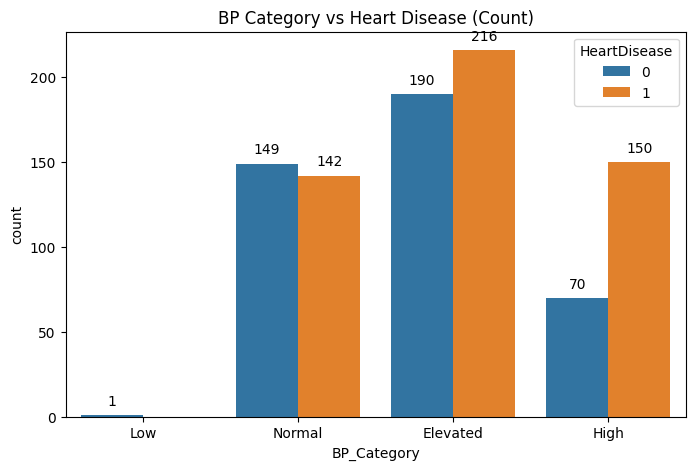

In [20]:
plt.figure(figsize=(8,5))

ax = sns.countplot(data=df1, x='BP_Category', hue='HeartDisease')

# Add counts
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(f'{int(height)}',
                    (p.get_x() + p.get_width()/2, height),
                    ha='center', va='bottom',
                    xytext=(0,5),
                    textcoords='offset points')

plt.title("BP Category vs Heart Disease (Count)")
plt.show()

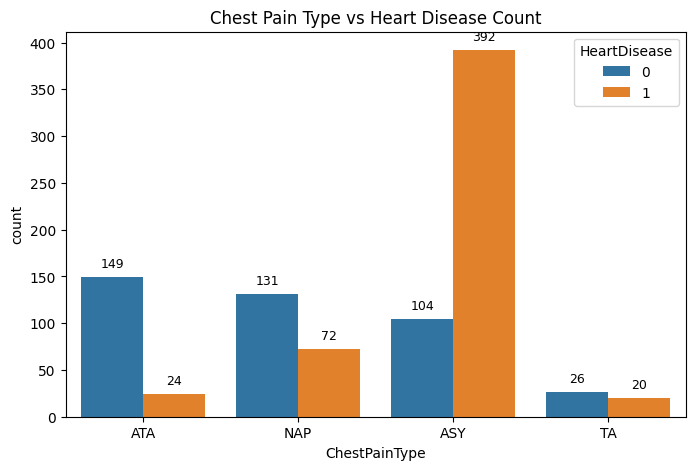

In [21]:
plt.figure(figsize=(8,5))

ax = sns.countplot(data=df, x='ChestPainType', hue='HeartDisease')

# Add count labels
for p in ax.patches:
    height = p.get_height()
    if height > 0:  # avoid showing 0 labels
        ax.annotate(f'{int(height)}',
                    (p.get_x() + p.get_width()/2, height),
                    ha='center', va='bottom',
                    fontsize=9,
                    xytext=(0, 5),
                    textcoords='offset points')

plt.title("Chest Pain Type vs Heart Disease Count")
plt.show()

In [22]:
Cat_col=df.select_dtypes(include="object").columns
Cat_col

Index(['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope'], dtype='object')

Encoding

**converting categorical values to numeric**

1. sex: M=0,F=1
2. chest pain type: ATA=0, NSP=1, ASY=2, TA=3
3. RestingEcg: Norma=0, ST=1, LVH=2
4. ExerciseAngina: N=0, Y=1
5. ST_Slope: UP=0, Flat=1, Down=2


In [23]:
for col in Cat_col:
    print(col)
    print((df[col].unique()),list(range(df[col].nunique())))
    df[col].replace((df[col].unique()),range(df[col].nunique()), inplace=True)
    print()

Sex
['M' 'F'] [0, 1]

ChestPainType
['ATA' 'NAP' 'ASY' 'TA'] [0, 1, 2, 3]

RestingECG
['Normal' 'ST' 'LVH'] [0, 1, 2]

ExerciseAngina
['N' 'Y'] [0, 1]

ST_Slope
['Up' 'Flat' 'Down'] [0, 1, 2]



In [24]:
df

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,0,0,140.0,289.0,0,0,172,0,0.0,0,0
1,49,1,1,160.0,180.0,0,0,156,0,1.0,1,1
2,37,0,0,130.0,283.0,0,1,98,0,0.0,0,0
3,48,1,2,138.0,214.0,0,0,108,1,1.5,1,1
4,54,0,1,150.0,195.0,0,0,122,0,0.0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,0,3,110.0,264.0,0,0,132,0,1.2,1,1
914,68,0,2,144.0,193.0,1,0,141,0,3.4,1,1
915,57,0,2,130.0,131.0,0,0,115,1,1.2,1,1
916,57,1,0,130.0,236.0,0,2,174,0,0.0,1,1


Correlation Matrix

Text(0.5, 1.0, 'Correlation matrix')

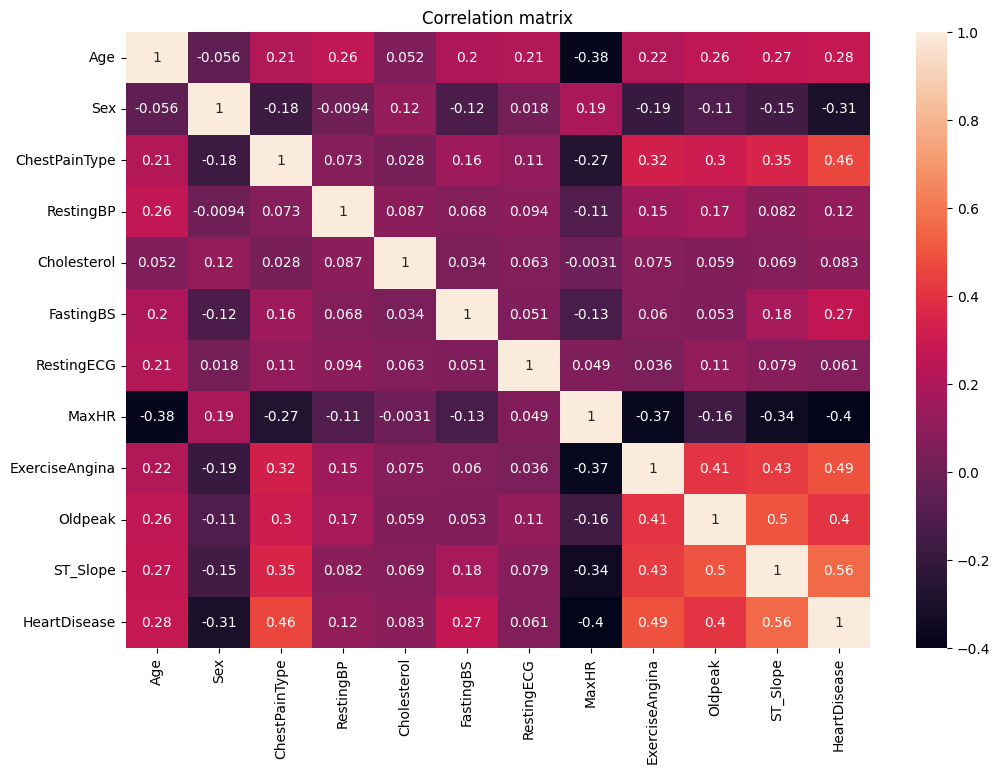

In [25]:
plt.figure(figsize = (12, 8))

corr = df.corr()

sns.heatmap(corr, annot=True)
plt.title('Correlation matrix')

Change Column Type into int

In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    int64  
 2   ChestPainType   918 non-null    int64  
 3   RestingBP       918 non-null    float64
 4   Cholesterol     918 non-null    float64
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    int64  
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    int64  
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    int64  
 11  HeartDisease    918 non-null    int64  
dtypes: float64(3), int64(9)
memory usage: 86.2 KB


In [27]:
withoutOldPeak= df.columns
withoutOldPeak=withoutOldPeak.drop('Oldpeak')
df[withoutOldPeak]=df[withoutOldPeak].astype('int32')

In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int32  
 1   Sex             918 non-null    int32  
 2   ChestPainType   918 non-null    int32  
 3   RestingBP       918 non-null    int32  
 4   Cholesterol     918 non-null    int32  
 5   FastingBS       918 non-null    int32  
 6   RestingECG      918 non-null    int32  
 7   MaxHR           918 non-null    int32  
 8   ExerciseAngina  918 non-null    int32  
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    int32  
 11  HeartDisease    918 non-null    int32  
dtypes: float64(1), int32(11)
memory usage: 46.7 KB


**Model Building**

Train Test Split

In [29]:
from sklearn.model_selection import train_test_split

In [30]:
X_train,x_test,y_train,y_test =train_test_split(
    df.drop('HeartDisease', axis=1),
    df['HeartDisease'],
    test_size=0.2,
    random_state=42,
    stratify=df['HeartDisease']
)


In [31]:
X_train

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope
485,63,0,0,139,217,1,1,128,1,1.2,1
486,55,0,0,110,214,1,1,180,0,0.4,0
117,59,1,2,130,338,1,1,130,1,1.5,1
361,47,0,2,160,253,0,0,124,1,0.0,1
296,50,0,2,145,218,1,0,139,1,0.7,1
...,...,...,...,...,...,...,...,...,...,...,...
276,51,0,1,135,160,0,0,150,0,2.0,1
201,46,0,1,120,230,0,0,150,0,0.0,0
462,59,0,2,122,233,0,0,117,1,1.3,2
252,61,0,2,125,292,0,1,115,1,0.0,0


**Logistic Regression**

In [32]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [33]:
solver=['lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga']
best_solver=''
test_score=np.zeros(6) 
for i, n in enumerate(solver):
    lr=LogisticRegression(solver=n).fit(X_train, y_train)
    test_score[i]=lr.score(x_test,y_test)
    if lr.score(x_test,y_test)==test_score.max():
        best_solver = n
print(best_solver)
lr=LogisticRegression(solver=best_solver)
lr.fit(X_train,y_train)

newton-cholesky


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [34]:
lr_pred=lr.predict(x_test)
print(f'LogisticRegression Score: {accuracy_score(y_test, lr_pred)}')

LogisticRegression Score: 0.8586956521739131


In [35]:
import pickle
# Save model
with open('logisticR.pkl', 'wb') as file:
    pickle.dump(lr, file)

**Support Vector Machine(SVM)**

In [36]:
from sklearn.svm import SVC
from sklearn.metrics import f1_score

kernels={'linear':0, 'poly':0, 'rbf':0, 'sigmoid':0}
best=''
for i in kernels:
    svm=SVC(kernel=i)
    svm.fit(X_train,y_train)
    yhat=svm.predict(x_test)
    kernels[i]=f1_score(y_test,yhat,average="weighted")
    if kernels[i] == max(kernels.values()):
        best=i
         
print(best)
svm = SVC(kernel=best)
svm.fit(X_train,y_train)

linear


,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [37]:
svm_pred= svm.predict(x_test)
print(f'SVM f1_score kernel({best}): {f1_score(y_test,svm_pred, average="weighted")}')

SVM f1_score kernel(linear): 0.8316173082290024


In [38]:
import pickle
# Save model
with open('SVM.pkl', 'wb') as file:
    pickle.dump(svm, file)

**Decision Tree**

In [39]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

In [40]:
dtree = DecisionTreeClassifier(class_weight='balanced')
param_grid = {
    'max_depth': [3,4,5,6,7,80],
    'min_samples_split':[2,3,4],
    'min_samples_leaf': [1,2,3,4],
    'random_state': [0,42]
}
grid_search= GridSearchCV(dtree,param_grid, cv=5)
grid_search.fit(X_train,y_train)
ctree=DecisionTreeClassifier(**grid_search.best_params_, class_weight='balanced')
ctree.fit(X_train,y_train)
                             

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current nod

In [41]:
dtc_pred=ctree.predict(x_test)
print("Decision Tree's Accuracy: ", accuracy_score(y_test,dtc_pred))

Decision Tree's Accuracy:  0.8097826086956522


In [42]:
# Save model
with open('DecisionTree.pkl', 'wb') as file:
    pickle.dump(ctree, file)

**Random Forest**

In [43]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

In [44]:
rfc = RandomForestClassifier()
param_grid = {
    'n_estimators': [50,100,150,500],
    'max_features':['sqrt','log2',None],
    'max_depth': [3,6,9,19],
    'max_leaf_nodes': [3,6,9],
    'random_state': [42]
}
grid_search= GridSearchCV(rfc,param_grid)
grid_search.fit(X_train,y_train)
rfctree=RandomForestClassifier(**grid_search.best_params_)
rfctree.fit(X_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",500
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",6
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",9
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_tru

In [45]:
rfc_pred=rfctree.predict(x_test)
print("RandomForestClassifier's Accuracy: ", accuracy_score(y_test,rfc_pred))

RandomForestClassifier's Accuracy:  0.8641304347826086


In [46]:
# Save model
with open('RandomForest.pkl', 'wb') as file:
    pickle.dump(rfctree, file)

In [47]:
import os
print(os.path.getsize('logisticR.pkl'))

988
